# Chapter 11: Scoring, Validation & Explanations

End-to-end scoring pipeline with holdout validation, model comparison, adversarial
validation, SHAP explanations, and error analysis.

**Sections:**
1. Run Scoring
2. Summary Metrics
3. Model Comparison Grid
4. Adversarial Pipeline Validation
5. Transformation Validation
6. Model Explanations (SHAP)
7. Customer Browser
8. Error Analysis
9. Export Results

In [1]:
from customer_retention.analysis.notebook_progress import track_and_export_previous
from customer_retention.analysis.visualization import display_table

track_and_export_previous("11_scoring_validation.ipynb")

import sys
from pathlib import Path

from customer_retention.core.compat import native_pd, to_pandas
from customer_retention.core.config.experiments import (  # noqa: F401
    FINDINGS_DIR,
    OUTPUT_DIR,
    setup_experiments_structure,
)


In [2]:
from customer_retention.core.compat.detection import is_databricks
from customer_retention.stages.scoring import ScoringConfig, ScoringDataLoader

if is_databricks():
    try:
        config = ScoringConfig.from_databricks()
    except ValueError as e:
        import os
        print(f"ERROR: {e}")
        print("\nDiagnostic info:")
        print(f"  CR_EXPERIMENT_NAME = {os.environ.get('CR_EXPERIMENT_NAME', '(not set)')}")
        print(f"  CR_CATALOG = {os.environ.get('CR_CATALOG', '(not set)')}")
        print(f"  CR_SCHEMA = {os.environ.get('CR_SCHEMA', '(not set)')}")
        print("\nOn Databricks, experiments are created under /Users/{username}/.")
        print("Set CR_EXPERIMENT_NAME to the full path, e.g.:")
        print('  os.environ["CR_EXPERIMENT_NAME"] = "/Users/you@example.com/customer_churn"')
        raise
else:
    generated_dir = Path("../generated_pipelines/local")
    pipeline_dirs = sorted(generated_dir.glob("*/config.py"))
    if not pipeline_dirs:
        raise FileNotFoundError(
            f"No generated pipeline found under {generated_dir}. Run notebook 10 first."
        )
    config = ScoringConfig.from_local_config(pipeline_dirs[-1].parent)

loader = ScoringDataLoader(config)

PIPELINE_NAME = config.pipeline_name
TARGET_COLUMN = config.target_column
ENTITY_KEY = config.entity_key
RECOMMENDATIONS_HASH = config.recommendations_hash
ORIGINAL_COLUMN = config.original_column

print(f"Pipeline: {PIPELINE_NAME}")
print(f"Platform: {'Databricks' if config.is_databricks else 'Local'}")
print(f"Experiments dir: {config.experiments_dir}")
print(f"Recommendations hash: {RECOMMENDATIONS_HASH}")

Pipeline: customer_churn
Platform: Local
Experiments dir: /Users/Vital/python/CustomerRetention/experiments
Recommendations hash: 76e2681f


## 11.1 Run Scoring

In [3]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import numpy as np
import xgboost as xgb

from customer_retention.transforms import ArtifactStore, TransformExecutor

_registry = ArtifactStore.from_manifest(Path(config.artifacts_path) / "manifest.yaml")
_executor = TransformExecutor()

ENCODINGS, SCALINGS = loader.load_transforms()

PREDICTIONS_PATH = config.production_dir / "data" / "scoring" / "predictions.parquet"

mlflow.set_tracking_uri(config.mlflow_tracking_uri)

features_df = loader.load_gold_features_distributed()

_SCORING_AVAILABLE = True

if ORIGINAL_COLUMN not in features_df.columns:
    print(
        f"No holdout found (column '{ORIGINAL_COLUMN}' missing). "
        "Holdout must be created in silver layer BEFORE gold layer feature computation.\n"
        "Skipping scoring validation."
    )
    _SCORING_AVAILABLE = False
    predictions_df = native_pd.DataFrame(columns=[ENTITY_KEY, "prediction", "probability", "actual", "correct"])

if _SCORING_AVAILABLE:
    scoring_mask = features_df[TARGET_COLUMN].isna() & features_df[ORIGINAL_COLUMN].notna()
    scoring_df = to_pandas(features_df[scoring_mask]).copy()
    print(f"Found {len(scoring_df):,} holdout records for scoring")

    scoring_features = loader.load_scoring_features(scoring_df)

    model, model_uri = loader.load_model()
    print(f"Loading model: {model_uri}")

    _SCORING_AVAILABLE = True


    def prepare_features(df):
        return loader.prepare_features(df, ENCODINGS + SCALINGS, _executor, _registry)


    X = prepare_features(scoring_features)
    y_true = scoring_features[ORIGINAL_COLUMN].to_numpy()

    if X.shape[1] == 0:
        print(
            "WARNING: Feature matrix has 0 columns after preparation.\n"
            "The model was likely trained before feature selection was fixed.\n"
            "Re-run notebooks 08 and 10 to retrain, then re-run this notebook.\n"
            "Skipping scoring validation."
        )
        _SCORING_AVAILABLE = False
        predictions_df = native_pd.DataFrame(columns=[ENTITY_KEY, "prediction", "probability", "actual", "correct"])

    if _SCORING_AVAILABLE:
        X, _missing_feats, _extra_feats = loader.align_features_to_model(X, model)
        if _missing_feats:
            print(f"WARNING: {len(_missing_feats)} features missing from scoring data (filled with 0):")
            for f in _missing_feats[:10]:
                print(f"  - {f}")
            if len(_missing_feats) > 10:
                print(f"  ... and {len(_missing_feats) - 10} more")
        if _extra_feats:
            print(f"INFO: {len(_extra_feats)} extra features in scoring data (dropped)")

    if _SCORING_AVAILABLE:
        print("Generating predictions...")
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X)[:, 1]
        else:
            y_proba = model.predict(xgb.DMatrix(X, feature_names=list(X.columns)))
        y_pred = (y_proba >= 0.5).astype(int)

        from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

        metrics = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else 0.0,
        }
        print("\nValidation Metrics (vs original values):")
        for name, value in metrics.items():
            print(f"  {name}: {value:.4f}")

        predictions_df = native_pd.DataFrame({
            ENTITY_KEY: scoring_df[ENTITY_KEY].to_numpy(),
            "prediction": y_pred,
            "probability": y_proba,
            "actual": y_true,
            "correct": (y_pred == y_true).astype(int),
        })
        PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
        predictions_df.to_parquet(PREDICTIONS_PATH, index=False)
        print(f"\nPredictions saved: {PREDICTIONS_PATH}")
        print(f"Correct: {predictions_df['correct'].sum():,}/{len(predictions_df):,} ({predictions_df['correct'].mean():.1%})")

Found 201,919 holdout records for scoring


2026/02/24 12:31:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas


2026/02/24 12:31:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables


2026/02/24 12:31:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types


2026/02/24 12:31:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints


...

2026/02/24 12:31:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments


2026/02/24 12:31:30 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/02/24 12:31:30 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Loading model: runs:/8ed19847ba8845bcb4dbc44598f12970/model_logistic_regression_76e2681f


  - campaign_type_mode_24h
  - subject_line_category_mode_24h
  - device_type_mode_24h
  - campaign_type_mode_7d
  - subject_line_category_mode_7d
  - device_type_mode_7d
  - campaign_type_mode_30d
  - subject_line_category_mode_30d
  - device_type_mode_30d
  - campaign_type_mode_90d
  ... and 11 more
INFO: 9 extra features in scoring data (dropped)
Generating predictions...

Validation Metrics (vs original values):
  accuracy: 0.9998
  precision: 0.9785
  recall: 1.0000
  f1: 0.9891
  roc_auc: 1.0000

Predictions saved: /Users/Vital/python/CustomerRetention/experiments/data/scoring/predictions.parquet
Correct: 201,888/201,919 (100.0%)


## 11.2 Summary Metrics

In [4]:
if _SCORING_AVAILABLE:
    from sklearn.metrics import (
        accuracy_score,
        confusion_matrix,
        f1_score,
        precision_score,
        recall_score,
        roc_auc_score,
    )

    y_true = predictions_df["actual"]
    y_pred = predictions_df["prediction"]
    y_proba = predictions_df["probability"]

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else 0.0,
    }

    print("\n=== Scoring Validation Metrics ===")
    for name, value in metrics.items():
        print(f"  {name}: {value:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
    print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")
else:
    print("Sections 11.2-11.9 skipped: retrain model via notebooks 08 + 10")


=== Scoring Validation Metrics ===
  Accuracy: 0.9998
  Precision: 0.9785
  Recall: 1.0000
  F1 Score: 0.9891
  ROC-AUC: 1.0000

Confusion Matrix:
  TN=200,479  FP=31
  FN=0  TP=1,409


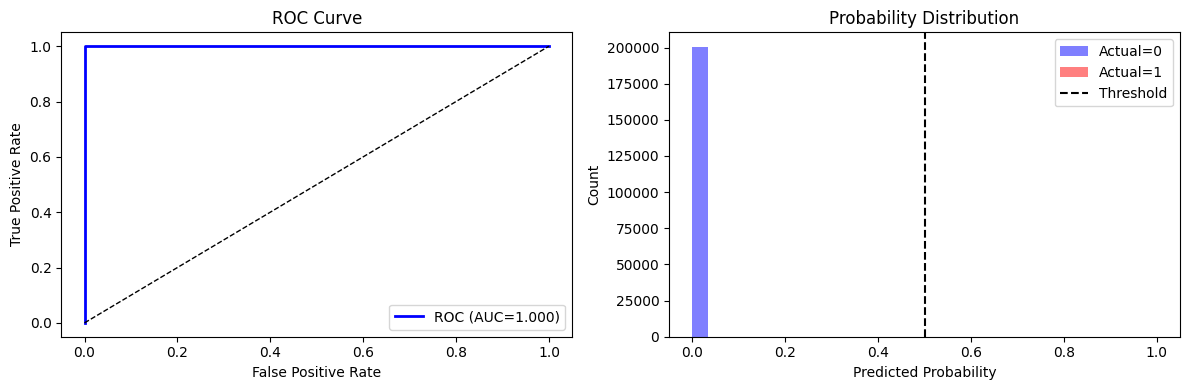

In [5]:
if _SCORING_AVAILABLE:
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    axes[0].plot(fpr, tpr, "b-", lw=2, label=f"ROC (AUC={metrics['ROC-AUC']:.3f})")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()

    axes[1].hist(y_proba[y_true == 0], bins=30, alpha=0.5, label="Actual=0", color="blue")
    axes[1].hist(y_proba[y_true == 1], bins=30, alpha=0.5, label="Actual=1", color="red")
    axes[1].axvline(x=0.5, color="black", linestyle="--", label="Threshold")
    axes[1].set_xlabel("Predicted Probability")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Probability Distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 11.3 Model Comparison Grid

Compare all trained models (Logistic Regression, Random Forest, XGBoost) on the holdout set.

**Grid Layout:**
- **Row 1**: Confusion matrices (counts and percentages)
- **Row 2**: ROC curves with AUC scores
- **Row 3**: Precision-Recall curves with PR-AUC scores

In [6]:
if _SCORING_AVAILABLE:
    from IPython.display import display
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        confusion_matrix,
        f1_score,
        precision_recall_curve,
        precision_score,
        recall_score,
        roc_auc_score,
        roc_curve,
    )

    mlflow.set_tracking_uri(config.mlflow_tracking_uri)
    client = mlflow.tracking.MlflowClient()
    experiment = client.get_experiment_by_name(PIPELINE_NAME)

    X_holdout = prepare_features(scoring_features)
    y_actual = predictions_df["actual"].to_numpy()

    logged_models = client.search_logged_models(experiment_ids=[experiment.experiment_id])

    model_types = ["logistic_regression", "random_forest", "xgboost"]
    model_display_names = ["Logistic Regression", "Random Forest", "XGBoost"]
    loaded_models = {}
    model_predictions = {}

    for model_type, display_name in zip(model_types, model_display_names):
        model_name_pattern = f"model_{model_type}"
        if RECOMMENDATIONS_HASH:
            model_name_pattern = f"{model_name_pattern}_{RECOMMENDATIONS_HASH}"

        matching_model = None
        for lm in logged_models:
            if lm.name == model_name_pattern:
                if matching_model is None or lm.creation_timestamp > matching_model.creation_timestamp:
                    matching_model = lm

        if matching_model:
            try:
                if "xgboost" in model_type:
                    m = mlflow.xgboost.load_model(matching_model.model_uri)
                else:
                    m = mlflow.sklearn.load_model(matching_model.model_uri)

                X_aligned, _, _ = loader.align_features_to_model(X_holdout, m)

                if "xgboost" in model_type:
                    dmatrix = xgb.DMatrix(X_aligned, feature_names=list(X_aligned.columns))
                    yp = m.predict(dmatrix)
                else:
                    yp = m.predict_proba(X_aligned)[:, 1]

                y_p = (yp > 0.5).astype(int)
                loaded_models[display_name] = m
                model_predictions[display_name] = {"y_pred": y_p, "y_proba": yp}
                print(f"Loaded {display_name}: ROC-AUC = {roc_auc_score(y_actual, yp):.4f}")
            except Exception as e:
                print(f"Could not load {display_name}: {e}")

    print(f"\nLoaded {len(loaded_models)} models for comparison")

Loaded Logistic Regression: ROC-AUC = 1.0000


Loaded Random Forest: ROC-AUC = 1.0000


Loaded XGBoost: ROC-AUC = 1.0000

Loaded 3 models for comparison


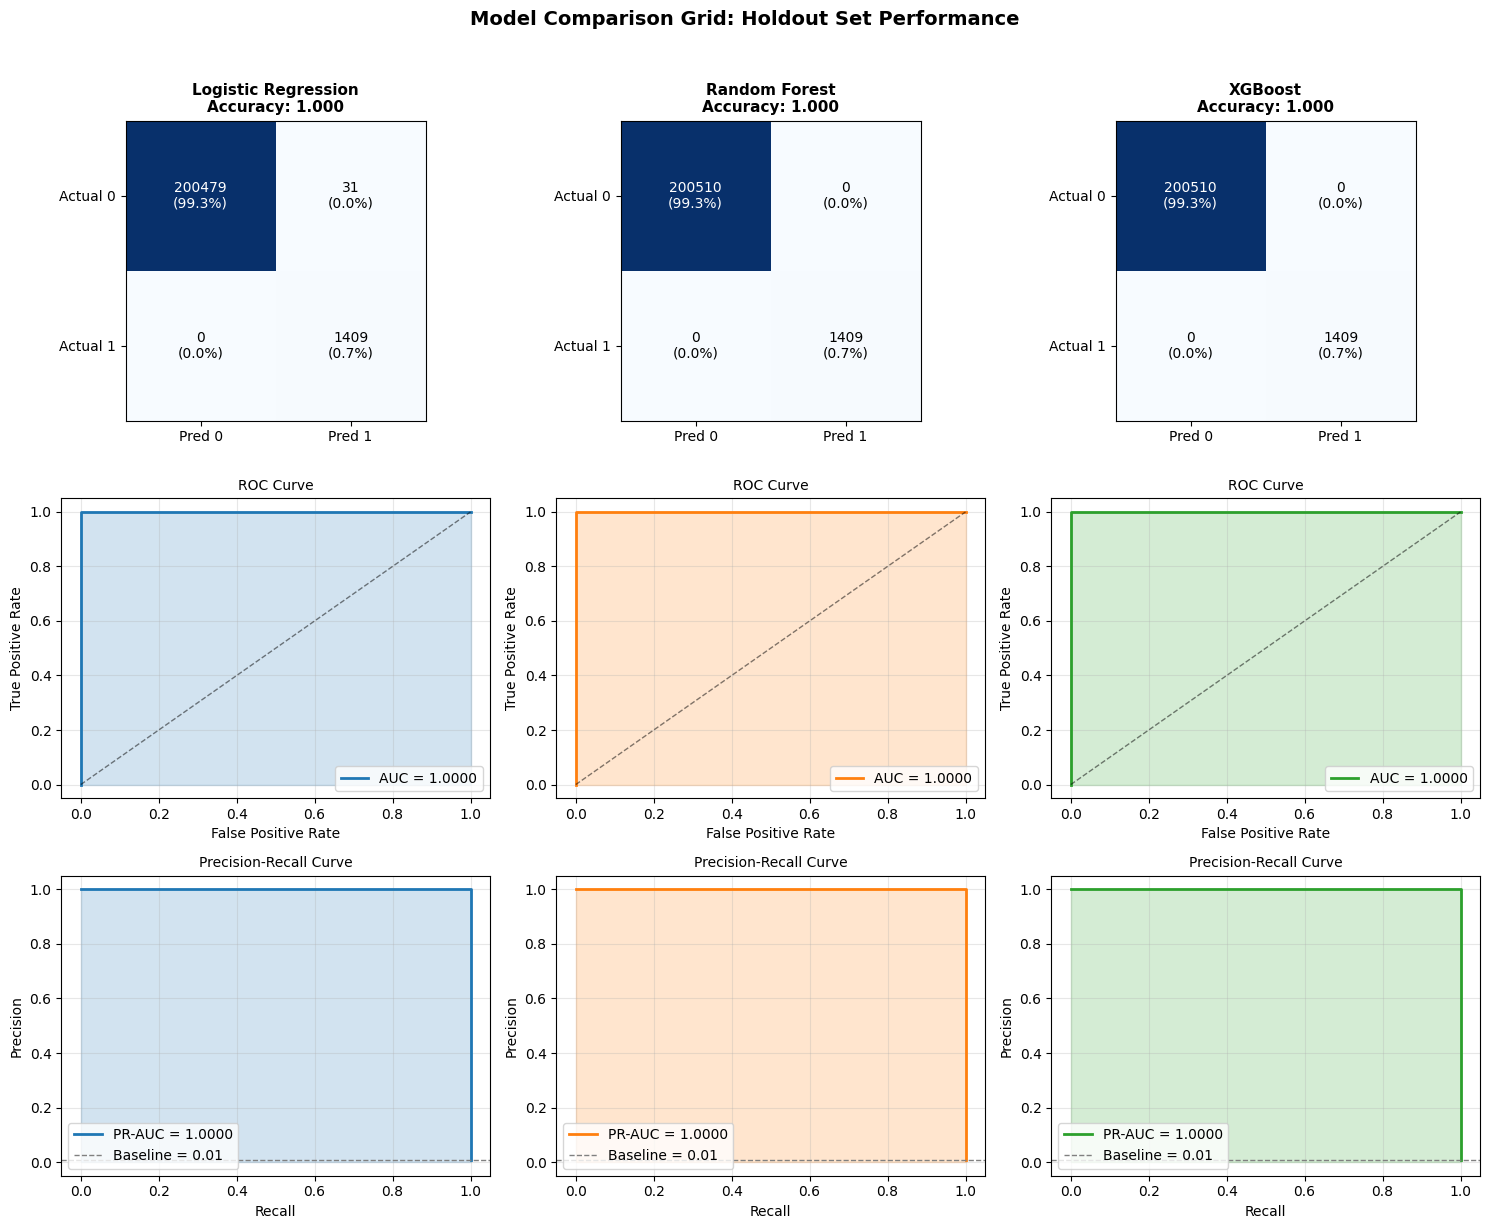

In [7]:
if _SCORING_AVAILABLE:
    n_models = len(model_predictions)
    if n_models > 0:
        fig, axes = plt.subplots(3, n_models, figsize=(5 * n_models, 12))
        if n_models == 1:
            axes = axes.reshape(-1, 1)

        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

        for col_idx, (name, preds) in enumerate(model_predictions.items()):
            y_p = preds["y_pred"]
            yp = preds["y_proba"]
            color = colors[col_idx % len(colors)]

            cm = confusion_matrix(y_actual, y_p)
            ax = axes[0, col_idx]
            ax.imshow(cm, cmap="Blues")
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(["Pred 0", "Pred 1"])
            ax.set_yticklabels(["Actual 0", "Actual 1"])
            for i in range(2):
                for j in range(2):
                    pct = cm[i, j] / cm.sum() * 100
                    ax.text(j, i, f"{cm[i, j]}\n({pct:.1f}%)", ha="center", va="center",
                            color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
            acc = accuracy_score(y_actual, y_p)
            ax.set_title(f"{name}\nAccuracy: {acc:.3f}", fontsize=11, fontweight="bold")

            ax = axes[1, col_idx]
            fpr, tpr, _ = roc_curve(y_actual, yp)
            auc = roc_auc_score(y_actual, yp)
            ax.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc:.4f}")
            ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
            ax.fill_between(fpr, tpr, alpha=0.2, color=color)
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.set_title("ROC Curve", fontsize=10)
            ax.legend(loc="lower right")
            ax.grid(True, alpha=0.3)

            ax = axes[2, col_idx]
            precision_vals, recall_vals, _ = precision_recall_curve(y_actual, yp)
            pr_auc = average_precision_score(y_actual, yp)
            ax.plot(recall_vals, precision_vals, color=color, lw=2, label=f"PR-AUC = {pr_auc:.4f}")
            baseline = y_actual.sum() / len(y_actual)
            ax.axhline(y=baseline, color="gray", linestyle="--", lw=1, label=f"Baseline = {baseline:.2f}")
            ax.fill_between(recall_vals, precision_vals, alpha=0.2, color=color)
            ax.set_xlabel("Recall")
            ax.set_ylabel("Precision")
            ax.set_title("Precision-Recall Curve", fontsize=10)
            ax.legend(loc="lower left")
            ax.grid(True, alpha=0.3)

        plt.suptitle("Model Comparison Grid: Holdout Set Performance",
                     fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print("No models loaded for comparison")

In [8]:
if _SCORING_AVAILABLE and model_predictions:
    comparison_results = []
    for name, preds in model_predictions.items():
        y_p = preds["y_pred"]
        yp = preds["y_proba"]
        comparison_results.append({
            "Model": name,
            "ROC-AUC": roc_auc_score(y_actual, yp),
            "PR-AUC": average_precision_score(y_actual, yp),
            "F1-Score": f1_score(y_actual, y_p),
            "Precision": precision_score(y_actual, y_p, zero_division=0),
            "Recall": recall_score(y_actual, y_p, zero_division=0),
            "Accuracy": accuracy_score(y_actual, y_p),
        })

    comparison_df = native_pd.DataFrame(comparison_results).set_index("Model")
    print("\n" + "=" * 70)
    print("MODEL COMPARISON SUMMARY (Holdout Set)")
    print("=" * 70)
    display_table(
        comparison_df.style
        .highlight_max(axis=0, props="background-color: #2e7d32; color: white")
        .format("{:.4f}")
    )

    best_model_name = comparison_df["ROC-AUC"].idxmax()
    best_auc = comparison_df.loc[best_model_name, "ROC-AUC"]
    print(f"\nBest Model: {best_model_name} (ROC-AUC = {best_auc:.4f})")


MODEL COMPARISON SUMMARY (Holdout Set)


,ROC-AUC,PR-AUC,F1-Score,Precision,Recall,Accuracy
Model,,,,,,
Logistic Regression,1.0000,1.0000,0.9891,0.9785,1.0000,0.9998
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



Best Model: Logistic Regression (ROC-AUC = 1.0000)


## 11.4 Adversarial Pipeline Validation

Validate that scoring pipeline produces identical features to training for holdout entities.
This catches transformation inconsistencies (e.g., scalers re-fit, encoders handling unseen values differently).

In [9]:
if _SCORING_AVAILABLE:
    gold_features = loader.load_gold_features()

    holdout_mask = gold_features[ORIGINAL_COLUMN].notna()
    holdout_gold = gold_features[holdout_mask].copy()
    print(f"Holdout entities for validation: {holdout_mask.sum():,}")

    scoring_entity_ids = set(scoring_features[ENTITY_KEY].to_numpy())
    gold_holdout = holdout_gold[holdout_gold[ENTITY_KEY].isin(scoring_entity_ids)]

    exclude_cols = {ENTITY_KEY, config.timestamp_column, TARGET_COLUMN, ORIGINAL_COLUMN}
    compare_cols = [
        c for c in gold_holdout.columns
        if c not in exclude_cols and not c.startswith("original_")
    ]

    print("\n" + "=" * 60)
    print("ADVERSARIAL PIPELINE VALIDATION")
    print("=" * 60)

    mismatches = []
    for col in compare_cols:
        if col in scoring_features.columns and col in gold_holdout.columns:
            g_vals = gold_holdout[col].to_numpy()
            s_vals = scoring_features.reindex(gold_holdout.index)[col].to_numpy()
            if native_pd.api.types.is_numeric_dtype(gold_holdout[col]):
                delta = np.abs(g_vals.astype(float) - s_vals.astype(float))
                max_delta = np.nanmax(delta) if len(delta) > 0 else 0
                if max_delta > 1e-6:
                    mismatches.append({"feature": col, "max_delta": max_delta})

    if not mismatches:
        print("\nPASSED: Scoring features match training features")
    else:
        print(f"\nFAILED: {len(mismatches)} features with drift")
        display_table(native_pd.DataFrame(mismatches).sort_values("max_delta", ascending=False))

Holdout entities for validation: 201,919

ADVERSARIAL PIPELINE VALIDATION



PASSED: Scoring features match training features


## 11.5 Transformation Validation

Use `validate_feature_transformation()` from the validation module to verify
encoding/scaling consistency between training and scoring.

In [10]:
if _SCORING_AVAILABLE:
    from customer_retention.stages.validation import validate_feature_transformation

    training_mask = gold_features[ORIGINAL_COLUMN].isna()
    training_subset = gold_features[training_mask].copy()
    scoring_subset = gold_features[~training_mask].copy()

    report = validate_feature_transformation(
        training_df=training_subset,
        scoring_df=scoring_subset,
        transform_fn=prepare_features,
        entity_column=ENTITY_KEY,
        verbose=True,
    )

    if report.passed:
        print("Transformation validation PASSED")
    else:
        print(f"Transformation validation FAILED: {len(report.feature_mismatches)} mismatches")

Validating transformation consistency...


Transformation validation: PASSED
Transformation validation PASSED


## 11.6 Model Explanations (SHAP)

In [11]:
if _SCORING_AVAILABLE:
    import shap

    mlflow.set_tracking_uri(config.mlflow_tracking_uri)
    client = mlflow.tracking.MlflowClient()

    experiment = client.get_experiment_by_name(PIPELINE_NAME)
    _hash_filter = f"tags.recommendations_hash = '{RECOMMENDATIONS_HASH}'" if RECOMMENDATIONS_HASH else ""
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=_hash_filter,
        order_by=["metrics.best_roc_auc DESC"],
        max_results=1,
    )
    parent_run = runs[0]

    best_model_tag = parent_run.data.tags.get("best_model", "random_forest")
    model_name = f"model_{best_model_tag}"
    if RECOMMENDATIONS_HASH:
        model_name = f"{model_name}_{RECOMMENDATIONS_HASH}"

    child_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=f"tags.mlflow.parentRunId = '{parent_run.info.run_id}'",
    )
    model_run = next((c for c in child_runs if c.info.run_name == best_model_tag), parent_run)

    loader_module = mlflow.xgboost if best_model_tag == "xgboost" else mlflow.sklearn
    model_uri = f"runs:/{model_run.info.run_id}/{model_name}"
    print(f"Loading model: {model_uri}")
    try:
        model = loader_module.load_model(model_uri)
    except Exception:
        logged_models = client.search_logged_models(experiment_ids=[experiment.experiment_id])
        _match = next((lm for lm in logged_models if lm.name == model_name and lm.source_run_id == model_run.info.run_id), None)
        if _match:
            model_uri = _match.model_uri
            model = loader_module.load_model(model_uri)
        else:
            raise
    print(f"Model type: {type(model).__name__}")

Loading model: runs:/8ed19847ba8845bcb4dbc44598f12970/model_logistic_regression_76e2681f


Model type: LogisticRegression


In [12]:
if _SCORING_AVAILABLE:
    X = prepare_features(scoring_features)
    X, _, _ = loader.align_features_to_model(X, model)
    feature_names = list(X.columns)
    print(f"Prepared {len(feature_names)} features for SHAP analysis")

Prepared 165 features for SHAP analysis


In [13]:
if _SCORING_AVAILABLE:
    print("Creating SHAP explainer (may take a moment)...")

    _is_tree_model = (
        hasattr(model, "estimators_")
        or hasattr(model, "get_booster")
        or type(model).__name__ == "Booster"
    )

    if _is_tree_model:
        explainer = shap.TreeExplainer(model)
        print(f"Using TreeExplainer ({type(model).__name__})")
    else:
        background_size = min(100, len(X))
        background = shap.sample(X, background_size)
        _max_evals = 2 * len(feature_names) + 1
        if hasattr(model, "predict_proba"):
            explainer = shap.Explainer(
                model.predict_proba, background,
                feature_names=feature_names, max_evals=_max_evals,
            )
        else:
            explainer = shap.Explainer(
                model, background,
                feature_names=feature_names, max_evals=_max_evals,
            )
        print(f"Using PermutationExplainer (max_evals={_max_evals})")

    print("Computing SHAP values...")
    shap_values = explainer(X)
    print(f"SHAP values computed for {len(shap_values)} records")

Creating SHAP explainer (may take a moment)...
Using PermutationExplainer (max_evals=331)
Computing SHAP values...


PermutationExplainer explainer:   0%|▏                                                                     | 424/201919 [00:00<?, ?it/s]

PermutationExplainer explainer:   0%|▏                                                             | 430/201919 [00:10<57:47, 58.11it/s]

PermutationExplainer explainer:   0%|▏                                                           | 436/201919 [00:10<1:01:53, 54.26it/s]

PermutationExplainer explainer:   0%|▏                                                           | 442/201919 [00:10<1:00:01, 55.94it/s]

...

PermutationExplainer explainer:  20%|███████████▉                                                | 40366/201919 [09:34<34:43, 77.55it/s]

PermutationExplainer explainer:  20%|███████████▉                                                | 40375/201919 [09:34<34:09, 78.80it/s]

PermutationExplainer explainer:  20%|████████████                                                | 40384/201919 [09:35<33:51, 79.52it/s]

PermutationExplainer explainer:  20%|████████████                                                | 40393/201919 [09:35<33:24, 80.56it/s]

PermutationExplainer explainer:  20%|████████████                                                | 40402/201919 [09:35<33:37, 80.06it/s]

In [ ]:
if _SCORING_AVAILABLE:
    if len(shap_values.shape) == 3:
        shap_vals = shap_values[:, :, 1]
    else:
        shap_vals = shap_values

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X, feature_names=feature_names, show=False, max_display=20)
    plt.title("Feature Importance (SHAP Summary)")
    plt.tight_layout()
    plt.show()

In [ ]:
if _SCORING_AVAILABLE:
    mean_shap = np.abs(shap_vals.values).mean(axis=0)
    importance_df = native_pd.DataFrame({
        "feature": feature_names,
        "importance": mean_shap,
    }).sort_values("importance", ascending=False)

    print("Top 15 Most Important Features:")
    display_table(importance_df.head(15))

## 11.7 Customer Browser

In [ ]:
if _SCORING_AVAILABLE:
    browser_df = predictions_df.merge(
        scoring_features[[ENTITY_KEY] + feature_names],
        on=ENTITY_KEY,
        how="left",
    )

    print(f"Customer browser ready with {len(browser_df):,} records")
    print("\nPrediction Distribution:")
    print(f"  Predicted Positive: {(browser_df['prediction'] == 1).sum():,}")
    print(f"  Predicted Negative: {(browser_df['prediction'] == 0).sum():,}")
    print(f"\nCorrect Predictions: {browser_df['correct'].sum():,}/{len(browser_df):,} ({browser_df['correct'].mean():.1%})")

In [ ]:
if _SCORING_AVAILABLE:
    def show_customer(idx: int):
        row = browser_df.iloc[idx]
        entity_id = row[ENTITY_KEY]

        print(f"=== Customer {entity_id} ===")
        print(f"Prediction: {int(row['prediction'])} (probability: {row['probability']:.3f})")
        print(f"Actual: {int(row['actual'])}")
        print(f"Correct: {'Yes' if row['correct'] else 'No'}")
        print()

        feature_vals = X.iloc[idx]
        if len(shap_values.shape) == 3:
            customer_shap = shap_values[idx, :, 1].values
        else:
            customer_shap = shap_values[idx].values

        feature_impact = native_pd.DataFrame({
            "feature": feature_names,
            "value": feature_vals.to_numpy(),
            "shap_impact": customer_shap,
        }).sort_values("shap_impact", key=abs, ascending=False)

        print("Top Contributing Features:")
        display_table(feature_impact.head(10))

        plt.figure(figsize=(10, 6))
        if len(shap_values.shape) == 3:
            shap.plots.waterfall(shap_values[idx, :, 1], max_display=10, show=False)
        else:
            shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
        plt.title(f"SHAP Explanation for Customer {entity_id}")
        plt.tight_layout()
        plt.show()

In [ ]:
if _SCORING_AVAILABLE:
    print("Showing first 3 customers:\n")
    for i in range(min(3, len(browser_df))):
        show_customer(i)
        print("\n" + "=" * 60 + "\n")

In [ ]:
if _SCORING_AVAILABLE:
    def lookup_customer(entity_id):
        mask = browser_df[ENTITY_KEY] == entity_id
        if not mask.any():
            print(f"Customer {entity_id} not found in scoring set")
            return
        idx = browser_df[mask].index[0]
        x_idx = browser_df.index.get_loc(idx)
        show_customer(x_idx)

    print("Available entity IDs (first 10):")
    print(browser_df[ENTITY_KEY].head(10).tolist())

## 11.8 Error Analysis

In [ ]:
if _SCORING_AVAILABLE:
    incorrect = browser_df[browser_df["correct"] == 0]
    print(f"Misclassified customers: {len(incorrect):,}")

    fp = incorrect[incorrect["prediction"] == 1]
    print(f"  False Positives: {len(fp):,}")

    fn = incorrect[incorrect["prediction"] == 0]
    print(f"  False Negatives: {len(fn):,}")

In [ ]:
if _SCORING_AVAILABLE and len(fp) > 0:
    print("\n=== Example False Positive ===")
    fp_idx = browser_df.index.get_loc(fp.index[0])
    show_customer(fp_idx)

In [ ]:
if _SCORING_AVAILABLE and len(fn) > 0:
    print("\n=== Example False Negative ===")
    fn_idx = browser_df.index.get_loc(fn.index[0])
    show_customer(fn_idx)

## 11.9 Export Results

In [ ]:
if _SCORING_AVAILABLE:
    if is_databricks():
        from customer_retention.core.compat import normalize_timestamp_columns, pandas_dtype_to_spark_schema
        from customer_retention.core.compat.detection import get_spark_session
        spark = get_spark_session()

    output_dir = config.scoring_output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    importance_df.to_csv(output_dir / "feature_importance.csv", index=False)
    print(f"Feature importance saved to {output_dir / 'feature_importance.csv'}")

    top_features = importance_df.head(10)["feature"].tolist()
    shap_by_entity = native_pd.DataFrame({ENTITY_KEY: scoring_features[ENTITY_KEY].to_numpy()})
    for feat in top_features:
        feat_idx = feature_names.index(feat)
        if len(shap_values.shape) == 3:
            shap_by_entity[f"shap_{feat}"] = shap_values[:, feat_idx, 1].values
        else:
            shap_by_entity[f"shap_{feat}"] = shap_values[:, feat_idx].values

    detailed_df = predictions_df.merge(shap_by_entity, on=ENTITY_KEY, how="left")
    detailed_df.to_parquet(output_dir / "predictions_with_shap.parquet", index=False)
    print(f"Detailed predictions with SHAP saved to {output_dir / 'predictions_with_shap.parquet'}")

    if is_databricks():
        table_name = f"{config.catalog}.{config.schema}.scoring_results"
        normalized = normalize_timestamp_columns(detailed_df)
        schema = pandas_dtype_to_spark_schema(normalized)
        spark.createDataFrame(normalized, schema=schema).write.format("delta") \
            .mode("overwrite").saveAsTable(table_name)
        print(f"Results saved to Delta table: {table_name}")


> **Save Reminder:** Save this notebook (Ctrl+S / Cmd+S) before running the next one.
> The next notebook will automatically export this notebook's HTML documentation from the saved file.